# NGCM Stream Sediment — Heavy Anomaly Detection Preprocessing Pipeline

**Dataset:** `NGCM-Stream-Sediment-Analysis-Updated.xlsx`  
**Target Features:** `As_ppm` (Arsenic), `Pb_ppm` (Lead), `Hg_ppb` (Mercury)  
**Coordinates:** `X` (Longitude), `Y` (Latitude)  
**Models to Feed:** One-Class SVM · Isolation Forest

---
## Pipeline Overview

| Step | Action | Why |
|------|--------|-----|
| 1 | Data Isolation & Cleaning | Extract target features; handle NaNs |
| 2 | Log Transformation | Correct right-skew of geochemical data |
| 3 | Robust Scaling | Equalise feature magnitudes; outlier-resistant |
| 4 | Coordinate Separation | Keep coords out of training; re-attach for mapping |

## 0 · Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Step 1 · Data Isolation & Cleaning

We extract only the **three chemical features** and the **two coordinate columns**.  
Coordinates are **immediately separated** so they are never seen by the models.

In [3]:
#  Load raw data 
RAW_PATH = '../Heavy-Metal-Anomaly-Detection/data/NGCM-Stream-Sediment-Analysis-Updated.xlsx'

df_raw = pd.read_excel(RAW_PATH)
print(f'Raw dataset : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

df_raw.sample(6)

Raw dataset : 10,004 rows × 73 columns


,FID,Shape *,gid,objectid,sampleno,X,Y,Si02_%,Al2O3_%,Fe2O3_%,...,Ta_ppm,W_ppm,U_ppm,Pt_ppb,Pd_ppb,In_ppm,F_ppm,Te_ppm,Tl_ppm,toposheet
932,932,Point,1324,1324,57E07/096/SS/00,77.464153,15.367222,64.33,11.68,5.13,...,0.857000,2.5,2.752000,0.8,1.1,0.0,0.0,0.0,0.0,57E07
7472,7472,Point,99250,99250,57A7/069/S/2013,76.482820,15.331330,68.43,13.74,4.15,...,1.484148,0.0,12.038577,0.0,0.0,0.0,0.0,0.0,0.0,57A07
4135,4135,Point,73641,73641,57B08/S/043/11,76.259444,14.063056,54.89,16.94,11.17,...,0.998000,2.5,1.597000,0.0,0.0,0.0,0.0,0.0,0.0,57B08
7934,7934,Point,109306,109306,57A14/026/S/14,76.964390,15.527110,60.58,12.71,3.92,...,0.737519,0.0,2.420657,0.0,0.0,0.0,0.0,0.0,0.0,57A14
5087,5087,Point,77665,77665,57B06/078/S/40,76.296667,14.599444,61.33,13.69,7.46,...,0.854000,2.5,2.107000,0.0,0.0,0.0,0.0,0.0,0.0,57B06
9668,9668,Point,278150,278332,57C05/057/S/17,76.259300,13.831400,57.00,16.06,4.06,...,1.580000,0.0,3.980000,0.0,0.0,0.0,0.0,0.0,0.0,57C05


In [3]:
df_raw.sample(10)

,FID,Shape *,gid,objectid,sampleno,X,Y,Si02_%,Al2O3_%,Fe2O3_%,...,Ta_ppm,W_ppm,U_ppm,Pt_ppb,Pd_ppb,In_ppm,F_ppm,Te_ppm,Tl_ppm,toposheet
5110,5110,Point,77736,77736,57B1/066/SS/2011-12,76.1758,14.8311,58.3100,11.3400,5.5100,...,0.8580,5.0000,1.6990,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57B01
8253,8253,Point,109745,109745,57A14/140/S/14,77.0000,15.6717,56.4300,11.5900,5.3700,...,1.3798,0.0000,2.9720,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57A14
6909,6909,Point,92964,92964,57A12/066/S/13-14,76.6767,15.0813,51.8400,14.6900,12.2900,...,0.6700,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57A12
6356,6356,Point,92006,92006,57A4/186/S/2013,76.0652,15.2440,58.9900,13.4100,6.2300,...,0.7533,0.0000,1.8519,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57A04
9027,9027,Point,110836,110836,57A10/171/S/14,76.5466,15.7259,56.6000,12.5700,5.6900,...,0.9494,0.0000,4.1907,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57A10
3481,3481,Point,5549,5549,57F02/027/SS/00,77.2315,14.5270,64.4100,15.1900,3.6500,...,0.6840,2.5000,3.3480,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57F02
1802,1802,Point,2963,2963,57F11/193/SS/12,77.6944,14.4932,62.1840,15.6500,4.3400,...,0.9970,2.5000,5.0080,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57F11
5275,5275,Point,78047,78047,57B06/181/S/12,76.4817,14.7278,60.7900,16.1100,4.9000,...,0.5312,2.5000,2.3524,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57B06
3938,3938,Point,73236,73236,57B12/086/S/12,76.5275,14.1171,54.8400,11.6500,5.3600,...,1.0298,2.5000,2.0906,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57B12
5339,5339,Point,85708,85708,57B14/128/S/15,76.7779,14.6717,64.1400,17.5000,4.0000,...,2.5922,0.0000,9.7621,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57B14


In [4]:
# Define columns of interest 
CHEM_FEATURES  = ['As_ppm', 'Pb_ppm', 'Hg_ppb']
COORD_FEATURES = ['X', 'Y']          # X = Longitude, Y = Latitude
ALL_COLS       = COORD_FEATURES + CHEM_FEATURES

df_selected = df_raw[ALL_COLS].copy()
print('Selected columns:', ALL_COLS)
df_selected.head()

Selected columns: ['X', 'Y', 'As_ppm', 'Pb_ppm', 'Hg_ppb']


,X,Y,As_ppm,Pb_ppm,Hg_ppb
0,77.1944,15.5991,4.9800,32.1000,6.0000
1,77.2130,15.5991,5.4300,26.8000,6.0000
2,77.2315,15.5991,4.4600,27.3000,5.0000
3,77.2500,15.5991,5.0800,29.2000,9.0000
4,77.0093,15.6171,5.7400,22.7000,7.0000


In [5]:
# Missing-value audit 
null_counts = df_selected.isnull().sum()
null_pct    = (null_counts / len(df_selected) * 100).round(2)

audit = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
print(' Missing Value Audit ')
print(audit)
print(f'\nTotal rows before cleaning: {len(df_selected):,}')

 Missing Value Audit 
        Missing Count  Missing %
X                   0     0.0000
Y                   0     0.0000
As_ppm              0     0.0000
Pb_ppm              0     0.0000
Hg_ppb              0     0.0000

Total rows before cleaning: 10,004


In [6]:
# Handle missing values 

MISSING_THRESHOLD = 5.0   # % — switch to imputation above this threshold

chem_null_max = null_pct[CHEM_FEATURES].max()

if chem_null_max == 0:
    df_clean = df_selected.copy()
    print(f' No missing values detected — no imputation needed.')

elif chem_null_max <= MISSING_THRESHOLD:
    df_clean = df_selected.dropna(subset=CHEM_FEATURES).copy()
    dropped = len(df_selected) - len(df_clean)
    print(f' Dropped {dropped} rows with NaN in chemical columns.')

else:
    imputer = SimpleImputer(strategy='median')
    df_clean = df_selected.copy()
    df_clean[CHEM_FEATURES] = imputer.fit_transform(df_selected[CHEM_FEATURES])
    print(f' Median imputation applied (max NaN% = {chem_null_max:.1f}%).')



 No missing values detected — no imputation needed.


In [7]:
# Descriptive statistics of raw chemistry 
print('Raw Chemistry Statistics')
df_clean[CHEM_FEATURES].describe().T.assign(
    skewness=df_clean[CHEM_FEATURES].skew()
)

Raw Chemistry Statistics


,count,mean,std,min,25%,50%,75%,max,skewness
As_ppm,10004.0000,3.0614,6.3975,0.0000,0.0000,1.4728,3.4400,150.0000,6.4237
Pb_ppm,10004.0000,17.1910,11.2616,0.0000,12.8000,16.7000,20.5000,482.9000,18.6864
Hg_ppb,10004.0000,5.5212,10.4861,0.0000,0.0000,5.0000,8.0000,570.0000,21.6099


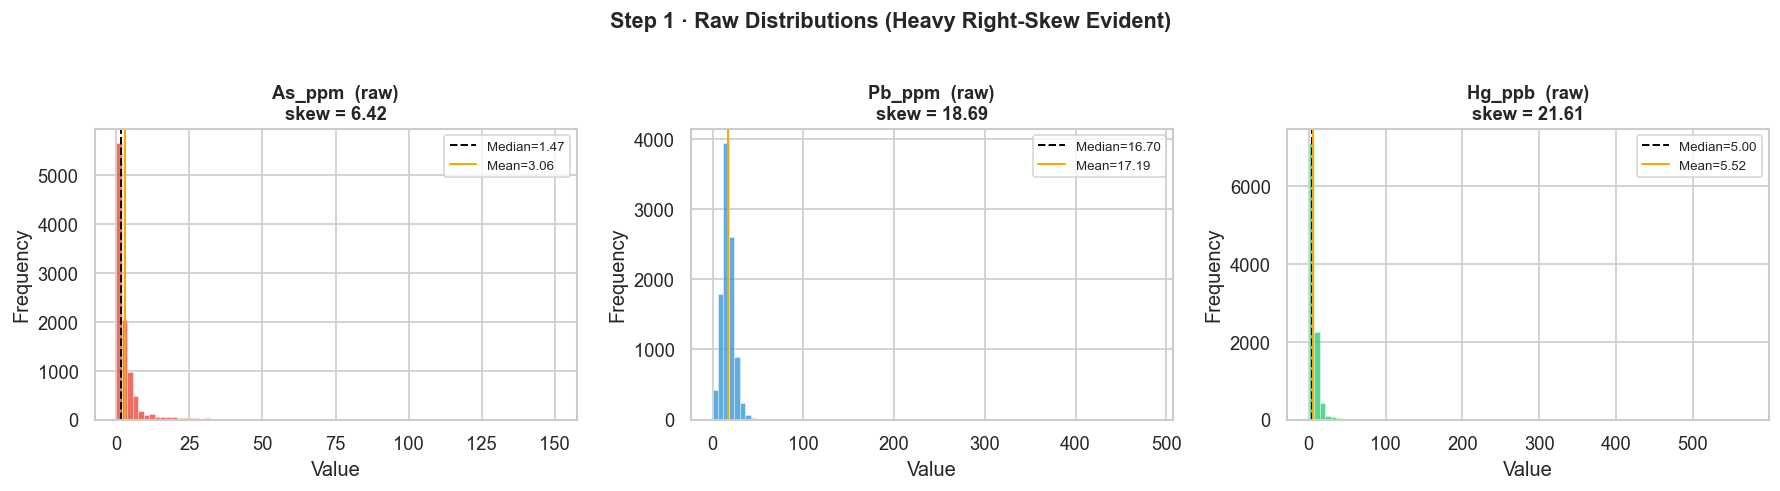

Saved → step1_raw_distributions.png


In [8]:
# Visualise raw distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#E74C3C', '#3498DB', '#2ECC71']

for ax, col, color in zip(axes, CHEM_FEATURES, colors):
    data = df_clean[col]
    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col}  (raw)\nskew = {data.skew():.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median={data.median():.2f}')
    ax.axvline(data.mean(),   color='orange', linestyle='-',  linewidth=1.2, label=f'Mean={data.mean():.2f}')
    ax.legend(fontsize=8)

fig.suptitle('Step 1 · Raw Distributions (Heavy Right-Skew Evident)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step1_raw_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → step1_raw_distributions.png')

---
## Step 2 · Log Transformation  (`numpy.log1p`)

Geochemical concentrations follow a **log-normal distribution**: most samples are near-zero, but a few spikes reach extreme values.  
Without transformation the anomaly detector treats *normal geological variation* (high values) as outliers.

> **`log1p(x)` = log(1 + x)`** — safe for zero values (avoids `log(0) = -∞`).

In [9]:
# Applying log1p to chemical features only
df_log = df_clean.copy()
df_log[CHEM_FEATURES] = np.log1p(df_clean[CHEM_FEATURES])

print('Post-Log Statistics')
df_log[CHEM_FEATURES].describe().T.assign(
    skewness=df_log[CHEM_FEATURES].skew()
)

Post-Log Statistics


,count,mean,std,min,25%,50%,75%,max,skewness
As_ppm,10004.0000,0.8865,0.9145,0.0000,0.0000,0.9054,1.4907,5.0173,0.7862
Pb_ppm,10004.0000,2.7992,0.4866,0.0000,2.6247,2.8736,3.0681,6.1819,-1.7290
Hg_ppb,10004.0000,1.2977,1.1144,0.0000,0.0000,1.7918,2.1972,6.3474,0.0143


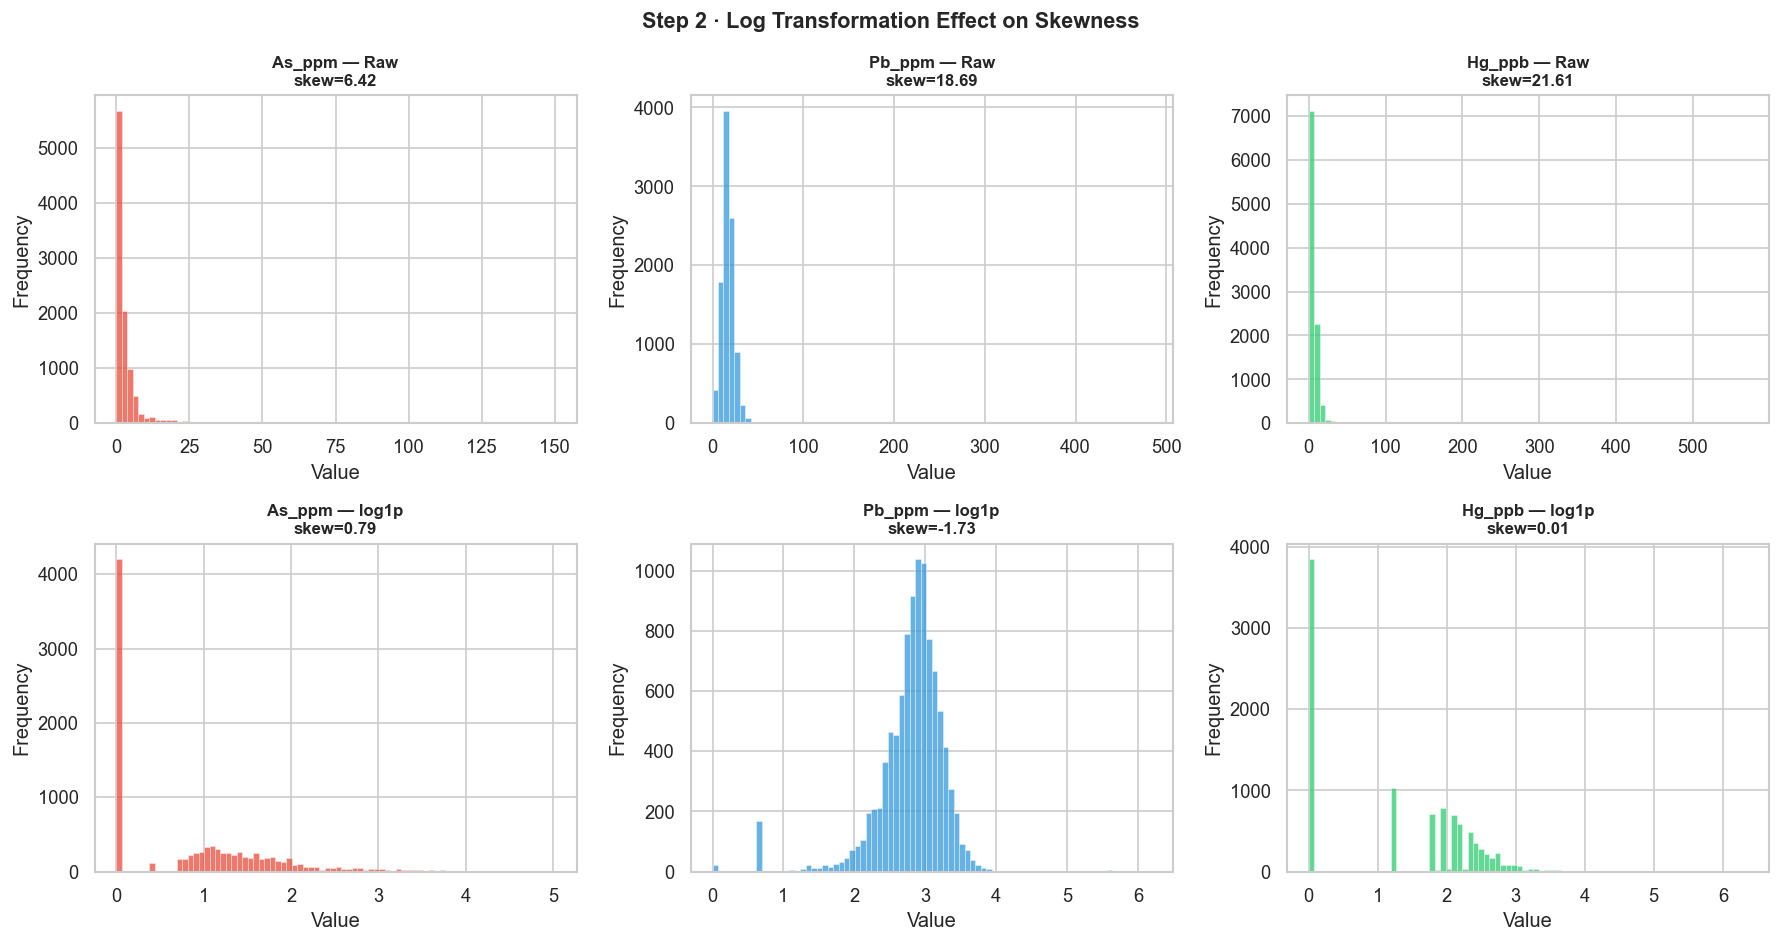

Saved → step2_log_transformation.png


In [10]:
# Before/After comparison plot 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['#E74C3C', '#3498DB', '#2ECC71']
labels = ['Before (Raw)', 'After (log1p)']

for col_idx, (col, color) in enumerate(zip(CHEM_FEATURES, colors)):
    for row_idx, (data, label) in enumerate([
        (df_clean[col], 'Raw'),
        (df_log[col],   'log1p')
    ]):
        ax = axes[row_idx, col_idx]
        ax.hist(data, bins=80, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
        ax.set_title(f'{col} — {label}\nskew={data.skew():.2f}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

fig.suptitle('Step 2 · Log Transformation Effect on Skewness', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('step2_log_transformation.png', bbox_inches='tight')
plt.show()
print('Saved → step2_log_transformation.png')

In [11]:
# Skewness improvement summary 
skew_before = df_clean[CHEM_FEATURES].skew().rename('Skew (Raw)')
skew_after  = df_log[CHEM_FEATURES].skew().rename('Skew (log1p)')
skew_df = pd.concat([skew_before, skew_after], axis=1)
skew_df['Reduction %'] = ((skew_before - skew_after) / skew_before.abs() * 100).round(1)
print('Skewness Reduction')
skew_df

Skewness Reduction


,Skew (Raw),Skew (log1p),Reduction %
As_ppm,6.4237,0.7862,87.8000
Pb_ppm,18.6864,-1.7290,109.3000
Hg_ppb,21.6099,0.0143,99.9000


---
## Step 3 · Step 4 · Coordinate Separation + Robust Scaling

### Why these two go together

**Step 4 — Coordinate Separation**  
We now split `X`/`Y` out of the training matrix. They are stored separately and re-attached *after* predictions for mapping.

**Step 3 — RobustScaler**  
One-Class SVM uses **Euclidean distance** in feature space.  
- `As_ppm` ranges 0–150 · `Pb_ppm` ranges 0–483 · `Hg_ppb` ranges 0–570  
- Without scaling, Mercury dominates the distance calculation.  
- `RobustScaler` uses **median + IQR** (not mean/std), so extreme outliers do not corrupt the scale.

In [12]:
# 4  Separate coordinates 
coords = df_log[COORD_FEATURES].copy().reset_index(drop=True)
X_chem = df_log[CHEM_FEATURES].copy().reset_index(drop=True)

print(f'Training matrix shape  : {X_chem.shape}  (models see ONLY this)')
print(f'Coordinates shape      : {coords.shape}  (re-attached after prediction)')
print()
print('Training matrix preview:')
X_chem.head()

Training matrix shape  : (10004, 3)  (models see ONLY this)
Coordinates shape      : (10004, 2)  (re-attached after prediction)

Training matrix preview:


,As_ppm,Pb_ppm,Hg_ppb
0,1.7884,3.4995,1.9459
1,1.8610,3.3250,1.9459
2,1.6974,3.3429,1.7918
3,1.8050,3.4078,2.3026
4,1.9081,3.1655,2.0794


In [13]:
# 3  Fit & apply RobustScaler
scaler = RobustScaler()
X_scaled_array = scaler.fit_transform(X_chem)
X_scaled = pd.DataFrame(X_scaled_array, columns=CHEM_FEATURES)

print('=== RobustScaler Parameters (Median / IQR) ===')
scaler_info = pd.DataFrame({
    'Feature'  : CHEM_FEATURES,
    'Center (Median)': scaler.center_,
    'Scale (IQR)'    : scaler.scale_
})
print(scaler_info.to_string(index=False))
print()
print('=== Scaled Data Statistics ===')
X_scaled.describe().T

=== RobustScaler Parameters (Median / IQR) ===
Feature  Center (Median)  Scale (IQR)
 As_ppm           0.9054       1.4907
 Pb_ppm           2.8736       0.4434
 Hg_ppb           1.7918       2.1972

=== Scaled Data Statistics ===


,count,mean,std,min,25%,50%,75%,max
As_ppm,10004.0000,-0.0126,0.6135,-0.6074,-0.6074,0.0000,0.3926,2.7585
Pb_ppm,10004.0000,-0.1677,1.0974,-6.4810,-0.5614,0.0000,0.4386,7.4615
Hg_ppb,10004.0000,-0.2249,0.5072,-0.8155,-0.8155,0.0000,0.1845,2.0734


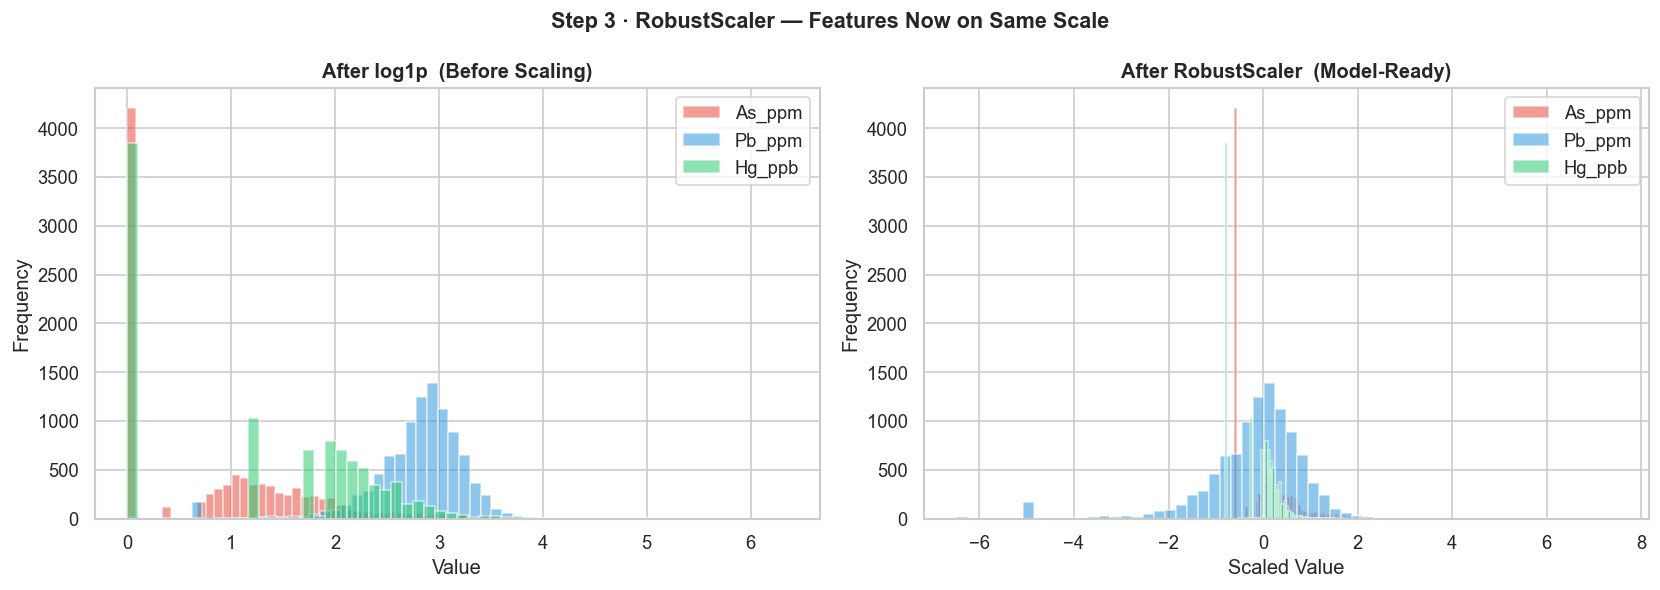

Saved → step3_robust_scaling.png


In [14]:
# 3b  Scaling comparison plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
ax = axes[0]
for col, color in zip(CHEM_FEATURES, ['#E74C3C','#3498DB','#2ECC71']):
    ax.hist(X_chem[col], bins=60, alpha=0.55, label=col, color=color, edgecolor='white')
ax.set_title('After log1p  (Before Scaling)', fontweight='bold')
ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
ax.legend()

# After scaling
ax = axes[1]
for col, color in zip(CHEM_FEATURES, ['#E74C3C','#3498DB','#2ECC71']):
    ax.hist(X_scaled[col], bins=60, alpha=0.55, label=col, color=color, edgecolor='white')
ax.set_title('After RobustScaler  (Model-Ready)', fontweight='bold')
ax.set_xlabel('Scaled Value'); ax.set_ylabel('Frequency')
ax.legend()

fig.suptitle('Step 3 · RobustScaler — Features Now on Same Scale', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('step3_robust_scaling.png', bbox_inches='tight')
plt.show()
print('Saved → step3_robust_scaling.png')

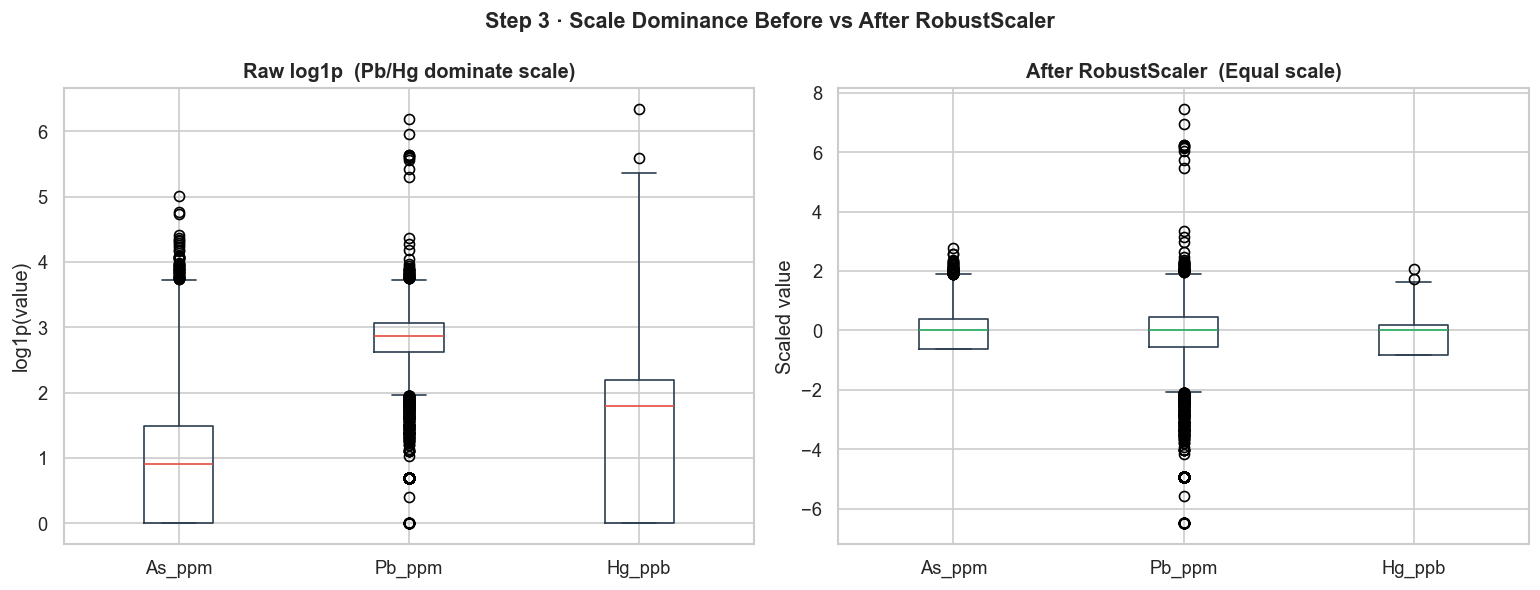

In [15]:
# ── 3c  Box-plot comparison (scale dominance check) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

X_chem.plot.box(ax=axes[0], vert=True,
                color={'boxes':'#2C3E50','whiskers':'#2C3E50',
                       'medians':'#E74C3C','caps':'#2C3E50'})
axes[0].set_title('Raw log1p  (Pb/Hg dominate scale)', fontweight='bold')
axes[0].set_ylabel('log1p(value)')

X_scaled.plot.box(ax=axes[1], vert=True,
                  color={'boxes':'#2C3E50','whiskers':'#2C3E50',
                         'medians':'#27AE60','caps':'#2C3E50'})
axes[1].set_title('After RobustScaler  (Equal scale)', fontweight='bold')
axes[1].set_ylabel('Scaled value')

fig.suptitle('Step 3 · Scale Dominance Before vs After RobustScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('step3_boxplot_comparison.png', bbox_inches='tight')
plt.show()

---
## Correlation Matrix — Scaled Features

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


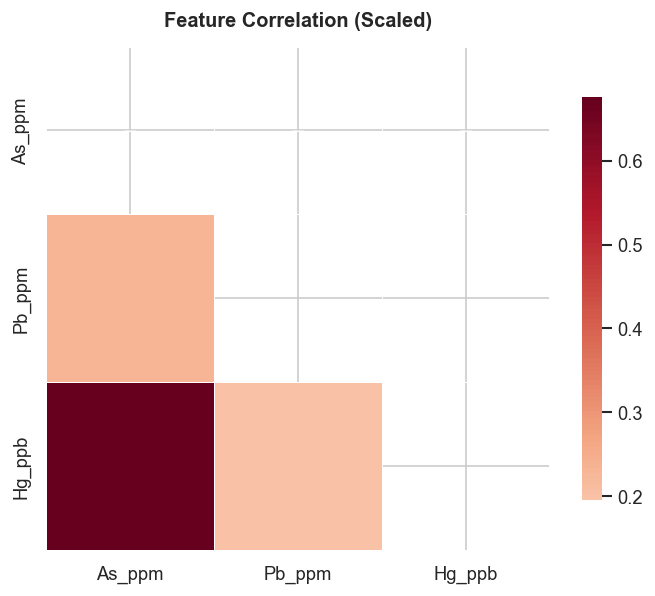

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = X_scaled.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation (Scaled)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

---
## Pipeline Summary & Final Outputs

In [17]:
# ── Final outputs ready for model training ──────────────────────────────────
print('=' * 60)
print('  PREPROCESSING COMPLETE — PIPELINE SUMMARY')
print('=' * 60)
print(f'  Rows loaded          : {len(df_raw):>8,}')
print(f'  Rows after cleaning  : {len(df_clean):>8,}')
print(f'  Chemical features    : {CHEM_FEATURES}')
print(f'  Transformations      : log1p → RobustScaler')
print(f'  Coordinate columns   : {COORD_FEATURES}  (separated)')
print('=' * 60)
print()
print('  Variables ready for model ingestion:')
print(f'    X_scaled  → shape {X_scaled.shape}   (feed directly to One-Class SVM / Isolation Forest)')
print(f'    coords    → shape {coords.shape}   (re-attach after .predict() for Folium mapping)')
print(f'    scaler    → fitted RobustScaler  (use .inverse_transform() if needed)')

  PREPROCESSING COMPLETE — PIPELINE SUMMARY
  Rows loaded          :   10,004
  Rows after cleaning  :   10,004
  Chemical features    : ['As_ppm', 'Pb_ppm', 'Hg_ppb']
  Transformations      : log1p → RobustScaler
  Coordinate columns   : ['X', 'Y']  (separated)

  Variables ready for model ingestion:
    X_scaled  → shape (10004, 3)   (feed directly to One-Class SVM / Isolation Forest)
    coords    → shape (10004, 2)   (re-attach after .predict() for Folium mapping)
    scaler    → fitted RobustScaler  (use .inverse_transform() if needed)


In [18]:
# ── Preview final training matrix ────────────────────────────────────────────
print('=== X_scaled (Training Matrix) ===')
display(X_scaled.head(10))

print('\n=== coords (Coordinate Store) ===')
display(coords.head(10))

=== X_scaled (Training Matrix) ===


,As_ppm,Pb_ppm,Hg_ppb
0,0.5924,1.4118,0.0702
1,0.6411,1.0182,0.0702
2,0.5314,1.0584,0.0000
3,0.6035,1.2050,0.2325
4,0.6727,0.6584,0.1309
5,0.7170,1.6137,-0.2453
6,0.6727,0.9607,0.2325
7,0.6707,1.1058,0.0702
8,0.6727,1.0979,0.1309
9,0.6337,1.0182,0.0000



=== coords (Coordinate Store) ===


,X,Y
0,77.1944,15.5991
1,77.2130,15.5991
2,77.2315,15.5991
3,77.2500,15.5991
4,77.0093,15.6171
5,77.0278,15.6171
6,77.0463,15.6171
7,77.0648,15.6171
8,77.0833,15.6171
9,77.1019,15.6171


In [19]:
# ── Save preprocessed data to CSV for downstream use ────────────────────────
X_scaled.to_csv('X_scaled_features.csv', index=False)
coords.to_csv('coords.csv', index=False)

# Combined (features + coords) — useful for inspection
df_combined = pd.concat([coords, X_scaled], axis=1)
df_combined.to_csv('preprocessed_combined.csv', index=False)

print('✅  Saved:')
print('    X_scaled_features.csv   → model training input')
print('    coords.csv              → coordinate store')
print('    preprocessed_combined.csv → full inspection file')

✅  Saved:
    X_scaled_features.csv   → model training input
    coords.csv              → coordinate store
    preprocessed_combined.csv → full inspection file


In [23]:
from ydata_profiling import ProfileReport

# Initialize the report
profile = ProfileReport(df_raw, title="Heavy Metal Anomaly Detection Report", explorative=True)

# To view the report directly in a Jupyter Notebook/Lab
profile.to_notebook_iframe()

# Or to save the report as an external HTML file
profile.to_file("dataset_analysis_report.html")

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (/opt/anaconda3/lib/python3.11/site-packages/typing_extensions.py)

In [ ]:

from ydata_profiling import ProfileReport

# Initialize the report
profile = ProfileReport(df_raw, title="Heavy Metal Anomaly Detection Report", explorative=True)

# To view the report directly in a Jupyter Notebook/Lab
profile.to_notebook_iframe()

# Or to save the report as an external HTML file
profile.to_file("dataset_analysis_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████| 73/73 [00:00<00:00, 105.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]